In [1]:
import gc
import time
import warnings
import logging
import os
import subprocess
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from optuna.samplers import TPESampler
from sklearn.calibration import calibration_curve

subprocess.run([sys.executable, '-m', 'pip', 'install', 'lightgbm', 'optuna', '-q'], check=False)

import lightgbm as lgb
import optuna

warnings.filterwarnings('ignore')
logging.getLogger('lightgbm').setLevel(logging.ERROR)
logging.getLogger('optuna').setLevel(logging.ERROR)
optuna.logging.set_verbosity(optuna.logging.WARNING)
os.environ['PYTHONWARNINGS'] = 'ignore'

matplotlib.use('Agg')

USE_GPU    = torch.cuda.is_available()
LGB_DEVICE = 'gpu' if USE_GPU else 'cpu'
print(f'GPU: {USE_GPU}')

t0 = time.time()

!rm -rf /kaggle/working/*

GPU: True


In [2]:
DATA   = Path('/kaggle/input/competitions/march-machine-learning-mania-2026')
OUTPUT = Path('/kaggle/working')
OUTPUT.mkdir(exist_ok=True)

SEED      = 42
N_FOLDS   = 20
MIN_SEASON= 2003
VAL_SEASON= 2025
CLIP_LO   = 0.012
CLIP_HI   = 0.988
DECAY     = 0.82
np.random.seed(SEED)

print('March Machine Learning Mania 2026  |  Single-Model SKF-OOF Pipeline')
print(f'GPU={USE_GPU}  Folds={N_FOLDS}  MinSeason={MIN_SEASON}')
%matplotlib inline

March Machine Learning Mania 2026  |  Single-Model SKF-OOF Pipeline
GPU=True  Folds=20  MinSeason=2003


In [3]:
def _csv(name):
    p = DATA / name
    if not p.exists(): raise FileNotFoundError(p)
    return pd.read_csv(p)

mreg  = _csv('MRegularSeasonCompactResults.csv')
wreg  = _csv('WRegularSeasonCompactResults.csv')
mtrn  = _csv('MNCAATourneyCompactResults.csv')
wtrn  = _csv('WNCAATourneyCompactResults.csv')
mseed = _csv('MNCAATourneySeeds.csv')
wseed = _csv('WNCAATourneySeeds.csv')
mconf = _csv('MTeamConferences.csv')
wconf = _csv('WTeamConferences.csv')
mteam = _csv('MTeams.csv')
wteam = _csv('WTeams.csv')
mass  = _csv('MMasseyOrdinals.csv')
sub1  = _csv('SampleSubmissionStage1.csv')
sub2  = _csv('SampleSubmissionStage2.csv')

MDET  = DATA / 'MRegularSeasonDetailedResults.csv'
WDET  = DATA / 'WRegularSeasonDetailedResults.csv'

for s in [sub1, sub2]:
    s[['Season','T1','T2']] = s['ID'].str.split('_', expand=True).astype(int)

print(f'Men reg={len(mreg):,}  Women reg={len(wreg):,}')
print(f'Men trn={len(mtrn):,}  Women trn={len(wtrn):,}')
print(f'Massey={len(mass):,}  Sub1={len(sub1):,}  Sub2={len(sub2):,}')


Men reg=198,577  Women reg=142,507
Men trn=2,585  Women trn=1,717
Massey=5,865,001  Sub1=519,144  Sub2=132,133


In [4]:
def elo_ratings(compact, k_reg=20, k_trn=32, init=1500, home=80,
                rev=0.35, cap=28, trn_start=134):
    def _exp(a, b): return 1/(1+10**((b-a)/400))
    def _mmul(m): return np.log(min(abs(m),cap)+1)/np.log(cap+1)

    rat = {}
    rows = []
    df = compact.sort_values(['Season','DayNum']).reset_index(drop=True)

    for season, grp in df.groupby('Season'):
        for t in list(rat):
            rat[t] += rev*(init - rat[t])
        saved = False
        for _, r in grp.iterrows():
            d, w, l = r['DayNum'], r['WTeamID'], r['LTeamID']
            diff = r['WScore'] - r['LScore']
            if d >= trn_start and not saved:
                for t, e in rat.items():
                    rows.append({'Season':season,'TeamID':t,'Elo':e})
                saved = True
            rat.setdefault(w, init); rat.setdefault(l, init)
            loc = r.get('WLoc','N')
            if   loc=='H': ew = _exp(rat[w]+home, rat[l])
            elif loc=='A': ew = _exp(rat[w], rat[l]+home)
            else:          ew = _exp(rat[w], rat[l])
            k  = (k_trn if d>=trn_start else k_reg) * _mmul(diff)
            dv = k*(1-ew)
            rat[w]+=dv; rat[l]-=dv
        if not saved:
            for t, e in rat.items():
                rows.append({'Season':season,'TeamID':t,'Elo':e})

    return pd.DataFrame(rows).groupby(['Season','TeamID'])['Elo'].last().reset_index()

m_elo = elo_ratings(pd.concat([mreg, mtrn], ignore_index=True))
w_elo = elo_ratings(pd.concat([wreg, wtrn], ignore_index=True))
m_elo_lu = m_elo.set_index(['Season','TeamID'])['Elo'].to_dict()
w_elo_lu = w_elo.set_index(['Season','TeamID'])['Elo'].to_dict()
print(f'Elo done  Men={len(m_elo_lu):,}  Women={len(w_elo_lu):,}')


Elo done  Men=14,206  Women=9,952


In [5]:
def box_stats(path):
    need = ['Season','DayNum','WTeamID','WScore','WFGM','WFGA','WFGM3',
            'WFTM','WFTA','WOR','WDR','WAst','WTO',
            'LTeamID','LScore','LFGM','LFGA','LFGM3',
            'LFTM','LFTA','LOR','LDR','LAst','LTO']
    hdr  = pd.read_csv(path, nrows=0).columns.tolist()
    cols = [c for c in need if c in hdr]
    df   = pd.read_csv(path, usecols=cols)
    df   = df[df['DayNum']<=132]
    eps  = 1e-6

    sides = []
    for pref, opp, win in [('W','L',1),('L','W',0)]:
        s = pd.DataFrame({
            'Season' : df['Season'],
            'TeamID' : df[f'{pref}TeamID'],
            'Win'    : win,
            'Pts'    : df[f'{pref}Score'],
            'PtsA'   : df[f'{opp}Score'],
            'FGM'    : df[f'{pref}FGM'],  'FGA': df[f'{pref}FGA'],
            'FGM3'   : df[f'{pref}FGM3'],
            'FTM'    : df[f'{pref}FTM'],  'FTA': df[f'{pref}FTA'],
            'OR'     : df[f'{pref}OR'],   'DR' : df[f'{pref}DR'],
            'OppDR'  : df[f'{opp}DR'],
            'Ast'    : df[f'{pref}Ast'],  'TO' : df[f'{pref}TO'],
        })
        sides.append(s)

    g = pd.concat(sides, ignore_index=True)
    g['Margin']  = g['Pts'] - g['PtsA']
    g['FTRateG'] = g['FTM'] / (g['FGA'] + eps)

    agg = g.groupby(['Season','TeamID']).agg(
        G       =('Win','count'), W=('Win','sum'),
        Pts     =('Pts','sum'),   PtsA=('PtsA','sum'),
        FGM     =('FGM','sum'),   FGA=('FGA','sum'),
        FGM3    =('FGM3','sum'),
        FTM     =('FTM','sum'),   FTA=('FTA','sum'),
        OR      =('OR','sum'),    OppDR=('OppDR','sum'),
        Ast     =('Ast','sum'),   TO=('TO','sum'),
        MarginSD=('Margin','std'),FTRateSD=('FTRateG','std'),
    ).reset_index().fillna(0)

    a = agg
    a['WinPct']  = a['W']   / a['G']
    a['AvgPts']  = a['Pts'] / a['G']
    a['AvgPtsA'] = a['PtsA']/ a['G']
    a['AvgMgn']  = a['AvgPts'] - a['AvgPtsA']
    a['eFG']     = (a['FGM'] + 0.5*a['FGM3']) / (a['FGA']+eps)
    a['TOV']     = a['TO']  / (a['FGA'] + 0.44*a['FTA'] + a['TO'] + eps)
    a['ORB']     = a['OR']  / (a['OR']  + a['OppDR'] + eps)
    a['FTR']     = a['FTM'] / (a['FGA'] + eps)
    a['FG3R']    = a['FGM3']/ (a['FGA'] + eps)
    a['AstTO']   = a['Ast'] / (a['TO']  + eps)
    a['Pyth']    = a['AvgPts']**11.5 / (a['AvgPts']**11.5 + a['AvgPtsA']**11.5 + eps)

    keep = ['Season','TeamID','WinPct','AvgPts','AvgPtsA','AvgMgn','MarginSD','eFG','TOV','ORB','FTR','FTRateSD','FG3R','AstTO','Pyth']
    del g; gc.collect()
    return a[keep].set_index(['Season','TeamID']).to_dict('index')

print('Loading detailed stats...')
m_box = box_stats(MDET); gc.collect()
w_box = box_stats(WDET); gc.collect()
print(f'Box stats done  Men={len(m_box):,}  Women={len(w_box):,}')

Loading detailed stats...
Box stats done  Men=8,346  Women=5,965


In [6]:
def massey_features(mass_df, systems=['POM','SAG','COL','DOL','MOR','WLK','RTH'], day=133):
    pre  = mass_df[mass_df['RankingDayNum']<=day]
    idx  = pre.groupby(['Season','SystemName','TeamID'])['RankingDayNum'].idxmax()
    pre  = pre.loc[idx].copy()
    pre  = pre[pre['SystemName'].isin(systems)]
    pivot= pre.pivot_table(index=['Season','TeamID'],columns='SystemName',
                           values='OrdinalRank',aggfunc='first').reset_index()
    pivot.columns.name = None
    scols= [c for c in systems if c in pivot.columns]
    for c in scols:
        pivot[c] = pivot.groupby('Season')[c].transform(lambda x:(x.max()-x+1)/x.count())
        pivot.rename(columns={c:f'M_{c}'}, inplace=True)
    pcols= [f'M_{c}' for c in scols if f'M_{c}' in pivot.columns]
    pivot['MasMean'] = pivot[pcols].mean(axis=1)
    pivot['MasMin']  = pivot[pcols].min(axis=1)
    pivot['MasTop3'] = pivot[pcols].apply(lambda r: r.nlargest(3).mean() if r.notna().sum()>=3 else r.mean(), axis=1)
    return pivot.set_index(['Season','TeamID']).to_dict('index')

def seed_lu(df):
    d = df.copy()
    d['SeedN'] = d['Seed'].str.extract(r'(\d+)').astype(int)
    return d.set_index(['Season','TeamID'])['SeedN'].to_dict()

def sos_lu(compact, elo_lu, init=1500):
    df = compact[compact['DayNum']<=132]
    w  = df[['Season','WTeamID','LTeamID']].rename(columns={'WTeamID':'T','LTeamID':'O'})
    l  = df[['Season','LTeamID','WTeamID']].rename(columns={'LTeamID':'T','WTeamID':'O'})
    b  = pd.concat([w,l], ignore_index=True)
    b['OE']= b.apply(lambda r: elo_lu.get((r['Season'],r['O']),init), axis=1)
    return b.groupby(['Season','T'])['OE'].mean().to_dict()

def momentum_lu(compact, n=8, decay=0.88):
    df = compact[compact['DayNum']<=132].copy()
    w  = df[['Season','DayNum','WTeamID']].rename(columns={'WTeamID':'T'}).assign(W=1)
    l  = df[['Season','DayNum','LTeamID']].rename(columns={'LTeamID':'T'}).assign(W=0)
    t  = pd.concat([w,l]).sort_values(['Season','T','DayNum'])
    t['ri'] = t.groupby(['Season','T']).cumcount(ascending=False)
    t  = t[t['ri']<n].copy()
    t['wt'] = decay**t['ri']
    g  = t.groupby(['Season','T'])
    return (g.apply(lambda x:(x['W']*x['wt']).sum()/x['wt'].sum())).to_dict()

def conf_lu(conf_df, compact):
    cl  = conf_df.set_index(['Season','TeamID'])['ConfAbbrev'].to_dict()
    w   = compact[['Season','WTeamID']].rename(columns={'WTeamID':'T'}).assign(W=1)
    l   = compact[['Season','LTeamID']].rename(columns={'LTeamID':'T'}).assign(W=0)
    tl  = pd.concat([w,l])
    tl['Conf'] = tl.apply(lambda r: cl.get((r['Season'],r['T']),'unk'), axis=1)
    cwr = tl.groupby(['Season','Conf'])['W'].mean().to_dict()
    return cl, cwr

def tourney_exp_lu(seeds_df, tourney_df, window=5):
    seeds_df = seeds_df.copy()
    seeds_df['SN'] = seeds_df['Seed'].str.extract(r'(\d+)').astype(int)
    wins = tourney_df.groupby(['Season','WTeamID']).size().reset_index(name='W')
    wins.columns = ['Season','TeamID','W']
    apps = seeds_df.merge(wins, on=['Season','TeamID'], how='left').fillna({'W':0})
    apps['DR'] = (apps['W']>=2).astype(int)
    lu = {}
    for s in sorted(apps['Season'].unique()):
        past = apps[apps['Season'].between(s-window, s-1)]
        for t, g in past.groupby('TeamID'):
            lu[(s,int(t))] = {
                'Apps': len(g), 'WPG': g['W'].mean(),
                'DRR': g['DR'].mean(), 'SeedAvg': g['SN'].mean()
            }
    return lu

POWER = {'acc','big_ten','big_twelve','sec','big_east','pac_twelve','wcc','a_ten'}

print('Building lookups...')
mass_lu  = massey_features(mass); del mass; gc.collect()
m_seed   = seed_lu(mseed);  w_seed  = seed_lu(wseed)
m_sos    = sos_lu(mreg, m_elo_lu); w_sos = sos_lu(wreg, w_elo_lu)
m_mom    = momentum_lu(mreg);      w_mom = momentum_lu(wreg)
m_cl, m_cwr = conf_lu(mconf, mreg)
w_cl, w_cwr = conf_lu(wconf, wreg)
m_exp    = tourney_exp_lu(mseed, mtrn)
w_exp    = tourney_exp_lu(wseed, wtrn)

all_trn = pd.concat([mtrn[['Season','WTeamID','LTeamID']],
                      wtrn[['Season','WTeamID','LTeamID']]], ignore_index=True)
all_trn['T1']  = all_trn[['WTeamID','LTeamID']].min(axis=1)
all_trn['T2']  = all_trn[['WTeamID','LTeamID']].max(axis=1)
all_trn['Win'] = (all_trn['WTeamID']==all_trn['T1']).astype(int)
h2h = all_trn.groupby(['T1','T2'])['Win'].agg(['sum','count'])
H2H_LU = ((h2h['sum']+1.5)/(h2h['count']+3)).to_dict()
H2H_N  = h2h['count'].clip(upper=6).to_dict()
print(f'H2H pairs={len(H2H_LU):,}  Massey teams={len(mass_lu):,}')


Building lookups...
H2H pairs=3,650  Massey teams=8,355


In [7]:
BOX_DEF = {'WinPct':0.5,'AvgPts':70,'AvgPtsA':70,'AvgMgn':0,'MarginSD':8,
            'eFG':0.49,'TOV':0.17,'ORB':0.30,'FTR':0.24,'FTRateSD':0.06,
            'FG3R':0.34,'AstTO':1.1,'Pyth':0.5}
EXP_DEF = {'Apps':0,'WPG':0,'DRR':0,'SeedAvg':8.5}

def team_vec(season, tid, elo_lu, box_lu, sos_d, mom_d,
             seed_d, cl, cwr, exp_d, is_men):
    elo  = elo_lu.get((season,tid), 1500)
    box  = box_lu.get((season,tid), BOX_DEF)
    sos  = sos_d.get((season,tid),  1500)
    mom  = mom_d.get((season,tid),  0.5)
    seed = seed_d.get((season,tid), 8.5)
    conf = cl.get((season,tid), 'unk')
    cw   = cwr.get((season,conf), 0.5)
    ipow = int(conf in POWER)
    exp  = exp_d.get((season,tid), EXP_DEF)

    mas = mass_lu.get((season,tid), {}) if is_men else {}

    v = [
        elo,
        box.get('WinPct',  BOX_DEF['WinPct']),
        box.get('AvgPts',  BOX_DEF['AvgPts']),
        box.get('AvgPtsA', BOX_DEF['AvgPtsA']),
        box.get('AvgMgn',  BOX_DEF['AvgMgn']),
        box.get('MarginSD',BOX_DEF['MarginSD']),
        box.get('eFG',     BOX_DEF['eFG']),
        box.get('TOV',     BOX_DEF['TOV']),
        box.get('ORB',     BOX_DEF['ORB']),
        box.get('FTR',     BOX_DEF['FTR']),
        box.get('FTRateSD',BOX_DEF['FTRateSD']),
        box.get('FG3R',    BOX_DEF['FG3R']),
        box.get('AstTO',   BOX_DEF['AstTO']),
        box.get('Pyth',    BOX_DEF['Pyth']),
        sos, mom, seed, cw, ipow,
        exp.get('Apps',   EXP_DEF['Apps']),
        exp.get('WPG',    EXP_DEF['WPG']),
        exp.get('DRR',    EXP_DEF['DRR']),
        exp.get('SeedAvg',EXP_DEF['SeedAvg']),
        mas.get('MasMean',0.5),
        mas.get('MasMin', 0.5),
        mas.get('MasTop3',0.5),
    ]
    return np.array(v, dtype=np.float32)

NVEC = len(team_vec(2024,1101,m_elo_lu,m_box,m_sos,m_mom,
                    m_seed,m_cl,m_cwr,m_exp,True))

def matchup_vec(season, t1, t2, is_women):
    elu  = w_elo_lu  if is_women else m_elo_lu
    box  = w_box     if is_women else m_box
    sos  = w_sos     if is_women else m_sos
    mom  = w_mom     if is_women else m_mom
    sed  = w_seed    if is_women else m_seed
    cl   = w_cl      if is_women else m_cl
    cwr  = w_cwr     if is_women else m_cwr
    exp  = w_exp     if is_women else m_exp
    men  = not is_women

    v1 = team_vec(season,t1,elu,box,sos,mom,sed,cl,cwr,exp,men)
    v2 = team_vec(season,t2,elu,box,sos,mom,sed,cl,cwr,exp,men)
    d  = v1 - v2

    h2h_key = (t1,t2)
    h2h_w   = H2H_LU.get(h2h_key, 0.5)
    h2h_n   = H2H_N.get(h2h_key,  0)

    elo_d   = v1[0] - v2[0]
    elo_p   = 1/(1+10**(-elo_d/400))
    seed_d  = v1[16]- v2[16]
    seed_p  = 1/(1+np.exp(0.4*seed_d))
    pyth_p  = v1[13]/(v1[13]+v2[13]+1e-9)
    mgn_d   = v1[4] - v2[4]

    extras = np.array([
        h2h_w, h2h_n,
        elo_p, seed_p, pyth_p,
        elo_d * seed_d,
        mgn_d * seed_d,
        v1[6] - v2[7],
        v1[15]* elo_d,
    ], dtype=np.float32)

    return np.concatenate([v1, v2, d, extras])

NCOLS = len(matchup_vec(2024,1101,1200,False))
print(f'Team vec={NVEC}  Matchup vec={NCOLS}')


Team vec=26  Matchup vec=87


In [8]:
def build_dataset(tourney_df, is_women, min_season=MIN_SEASON):
    df   = tourney_df[tourney_df['Season']>=min_season]
    rows, labels, seasons = [], [], []
    for _, r in tqdm(df.iterrows(), total=len(df), desc='Women' if is_women else 'Men  '):
        s, w, l = r['Season'], r['WTeamID'], r['LTeamID']
        t1, t2  = (w,l) if w<l else (l,w)
        out     = 1 if w<l else 0
        rows.append(matchup_vec(s, t1, t2, is_women))
        labels.append(out)
        seasons.append(s)
        rows.append(-1 * (rows[-1] * np.array(
            [-1]*NVEC + [-1]*NVEC + [1]*NVEC + [-1,-1,-1,-1,-1,-1,-1,-1,-1],
            dtype=np.float32)))
        rows[-1][:NVEC]       = matchup_vec(s,t2,t1,is_women)[:NVEC]
        rows[-1][NVEC:2*NVEC] = matchup_vec(s,t1,t2,is_women)[:NVEC]
        rows[-1][2*NVEC:]     = matchup_vec(s,t2,t1,is_women)[2*NVEC:]
        rows[-1] = matchup_vec(s, t2, t1, is_women)
        labels.append(1-out)
        seasons.append(s)
    X = np.array(rows, dtype=np.float32)
    y = np.array(labels, dtype=np.float32)
    s = np.array(seasons)
    return X, y, s

print('Building training data...')
Xm, ym, sm = build_dataset(mtrn, is_women=False)
Xw, yw, sw = build_dataset(wtrn, is_women=True)

X = np.vstack([Xm, Xw])
y = np.concatenate([ym, yw])
s = np.concatenate([sm, sw])
g = np.concatenate([np.zeros(len(ym)), np.ones(len(yw))])

print(f'Total rows={len(X):,}  Features={X.shape[1]}  Balance={y.mean():.3f}')
print(f'Men={len(ym):,}  Women={len(yw):,}')


Building training data...


Women: 100%|██████████| 1402/1402 [00:00<00:00, 5038.65it/s]

Total rows=5,702  Features=87  Balance=0.500
Men=2,898  Women=2,804


In [9]:
from optuna.samplers import TPESampler
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost', 'catboost', '-q'], check=False)

print('Tuning LightGBM with Optuna...')
imp = SimpleImputer(strategy='median')
X_clean = imp.fit_transform(X)

def _cv_brier(trial):
    params = {
        'objective'        : 'binary',
        'metric'           : 'binary_logloss',
        'verbose'          : -1,
        'device'           : LGB_DEVICE,
        'gpu_use_dp'       : True,
        'random_state'     : SEED,
        'learning_rate'    : trial.suggest_float('lr',  0.005, 0.06, log=True),
        'num_leaves'       : trial.suggest_int('nl',    16, 127),
        'max_depth'        : trial.suggest_int('md',    3, 8),
        'min_child_samples': trial.suggest_int('mcs',   3, 50),
        'feature_fraction' : trial.suggest_float('ff',  0.4, 1.0),
        'bagging_fraction' : trial.suggest_float('bf',  0.4, 1.0),
        'bagging_freq'     : 5,
        'reg_alpha'        : trial.suggest_float('ra',  1e-3, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('rl',  1e-3, 10.0, log=True),
        'min_split_gain'   : trial.suggest_float('msg', 0.0, 1.0),
        'extra_trees'      : trial.suggest_categorical('et', [True, False]),
    }
    uniq_s = sorted(np.unique(s))
    scores = []
    for ts in uniq_s[-5:]:
        tr = np.where(s < ts)[0]
        te = np.where(s == ts)[0]
        if len(tr) < 50 or len(te) == 0: continue
        w_tr = DECAY ** (ts - s[tr]); w_tr /= w_tr.mean()
        ds   = lgb.Dataset(X_clean[tr], label=y[tr], weight=w_tr)
        m    = lgb.train(params, ds, num_boost_round=500, callbacks=[lgb.log_evaluation(-1)])
        p    = m.predict(X_clean[te])
        scores.append(brier_score_loss(y[te], p))
    return float(np.mean(scores)) if scores else 0.25

study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=SEED, n_startup_trials=12, multivariate=True)
)
study.optimize(_cv_brier, n_trials=40, show_progress_bar=True)
BEST_P = study.best_params
print(f'Best trial Brier={study.best_value:.5f}')
print(f'Best params: {BEST_P}')

Tuning LightGBM with Optuna...


  0%|          | 0/40 [00:00<?, ?it/s]

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Best trial Brier=0.09872
Best params: {'lr': 0.0319887619441169, 'nl': 70, 'md': 3, 'mcs': 10, 'ff': 0.7796703446487512, 'bf': 0.8840045506957296, 'ra': 5.0202945949803865, 'rl': 0.0015124908369923186, 'msg': 0.3571816213239706, 'et': True}


In [10]:
print(f'\nStratified K-Fold OOF Training  (k={N_FOLDS}) ...')

FINAL_P = {
    'objective'        : 'binary',
    'metric'           : 'binary_logloss',
    'verbose'          : -1,
    'device'           : LGB_DEVICE,
    'gpu_use_dp'       : True,
    'random_state'     : SEED,
    'bagging_freq'     : 5,
    'learning_rate'    : BEST_P.get('lr',   0.05),
    'num_leaves'       : BEST_P.get('nl',   63),
    'max_depth'        : BEST_P.get('md',   6),
    'min_child_samples': BEST_P.get('mcs',  10),
    'feature_fraction' : BEST_P.get('ff',   0.8),
    'bagging_fraction' : BEST_P.get('bf',   0.8),
    'reg_alpha'        : BEST_P.get('ra',   0.1),
    'reg_lambda'       : BEST_P.get('rl',   0.1),
    'min_split_gain'   : BEST_P.get('msg',  0.0),
    'extra_trees'      : BEST_P.get('et',   False),
}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
oof_rf  = np.zeros(len(X))
oof_mlp = np.zeros(len(X))

models_lgb = []; models_xgb = []; models_cat = []
models_rf  = []; models_mlp = []
feat_imp = np.zeros(X_clean.shape[1])

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_clean, y.astype(int))):
    Xtr, Xvl = X_clean[tr_idx], X_clean[vl_idx]
    ytr, yvl = y[tr_idx],       y[vl_idx]
    str_     = s[tr_idx]
    max_s    = str_.max()
    w_tr     = DECAY ** (max_s - str_); w_tr /= w_tr.mean()

    # LightGBM
    ds_tr = lgb.Dataset(Xtr, label=ytr, weight=w_tr)
    ds_vl = lgb.Dataset(Xvl, label=yvl)
    m_lgb = lgb.train(FINAL_P, ds_tr, num_boost_round=6000, valid_sets=[ds_vl],
                      callbacks=[lgb.early_stopping(150, verbose=False), lgb.log_evaluation(500)])
    oof_lgb[vl_idx] = m_lgb.predict(Xvl)
    feat_imp += m_lgb.feature_importance(importance_type='gain')
    models_lgb.append(m_lgb)

    # XGBoost
    m_xgb = XGBClassifier(
        n_estimators=3000, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        use_label_encoder=False, eval_metric='logloss',
        early_stopping_rounds=150,
        device='cuda' if USE_GPU else 'cpu', random_state=SEED, verbosity=0
    )
    m_xgb.fit(Xtr, ytr, sample_weight=w_tr,
              eval_set=[(Xvl, yvl)], verbose=False)
    oof_xgb[vl_idx] = m_xgb.predict_proba(Xvl)[:, 1]
    models_xgb.append(m_xgb)

    # CatBoost
    m_cat = CatBoostClassifier(
        iterations=3000, learning_rate=0.05, depth=6,
        l2_leaf_reg=3, random_seed=SEED,
        task_type='GPU' if USE_GPU else 'CPU',
        eval_metric='Logloss', verbose=False
    )
    m_cat.fit(Xtr, ytr, sample_weight=w_tr,
              eval_set=(Xvl, yvl), early_stopping_rounds=150)
    oof_cat[vl_idx] = m_cat.predict_proba(Xvl)[:, 1]
    models_cat.append(m_cat)

    # Random Forest
    m_rf = RandomForestClassifier(
        n_estimators=500, max_depth=12, min_samples_leaf=5,
        max_features=0.6, random_state=SEED, n_jobs=-1
    )
    m_rf.fit(Xtr, ytr, sample_weight=w_tr)
    oof_rf[vl_idx] = m_rf.predict_proba(Xvl)[:, 1]
    models_rf.append(m_rf)

    # MLP
    scaler = StandardScaler()
    Xtr_s  = scaler.fit_transform(Xtr)
    Xvl_s  = scaler.transform(Xvl)
    m_mlp  = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), activation='relu',
        learning_rate_init=1e-3, max_iter=300, early_stopping=True,
        validation_fraction=0.1, random_state=SEED
    )
    m_mlp.fit(Xtr_s, ytr)
    oof_mlp[vl_idx] = m_mlp.predict_proba(Xvl_s)[:, 1]
    models_mlp.append((m_mlp, scaler))

    b_lgb = brier_score_loss(yvl, oof_lgb[vl_idx])
    b_xgb = brier_score_loss(yvl, oof_xgb[vl_idx])
    b_cat = brier_score_loss(yvl, oof_cat[vl_idx])
    b_rf  = brier_score_loss(yvl, oof_rf[vl_idx])
    b_mlp = brier_score_loss(yvl, oof_mlp[vl_idx])
    print(f'  Fold {fold+1:2d}  LGB={b_lgb:.4f}  XGB={b_xgb:.4f}  CAT={b_cat:.4f}  RF={b_rf:.4f}  MLP={b_mlp:.4f}')

feat_imp /= N_FOLDS

brier_lgb = brier_score_loss(y, oof_lgb)
brier_xgb = brier_score_loss(y, oof_xgb)
brier_cat = brier_score_loss(y, oof_cat)
brier_rf  = brier_score_loss(y, oof_rf)
brier_mlp = brier_score_loss(y, oof_mlp)
print(f'\nOOF Brier  LGB={brier_lgb:.5f}  XGB={brier_xgb:.5f}  CAT={brier_cat:.5f}  RF={brier_rf:.5f}  MLP={brier_mlp:.5f}')

raw_scores  = np.array([brier_lgb, brier_xgb, brier_cat, brier_rf, brier_mlp])
inv_brier   = 1.0 / raw_scores
W           = inv_brier / inv_brier.sum()
print(f'Ensemble weights  LGB={W[0]:.3f}  XGB={W[1]:.3f}  CAT={W[2]:.3f}  RF={W[3]:.3f}  MLP={W[4]:.3f}')

oof_ens = (W[0]*oof_lgb + W[1]*oof_xgb + W[2]*oof_cat + W[3]*oof_rf + W[4]*oof_mlp)
oof_brier = brier_score_loss(y, oof_ens)
print(f'OOF Brier (ensemble raw) : {oof_brier:.5f}')

iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(oof_ens, y)
oof_cal   = iso.predict(oof_ens)
cal_brier = brier_score_loss(y, oof_cal)
print(f'OOF Brier (ensemble cal) : {cal_brier:.5f}  (Δ={cal_brier-oof_brier:+.5f})')


Stratified K-Fold OOF Training  (k=20) ...
[500]	valid_0's binary_logloss: 0.306563
[1000]	valid_0's binary_logloss: 0.298544
  Fold  1  LGB=0.0993  XGB=0.0999  CAT=0.1073  RF=0.1063  MLP=0.0995
[500]	valid_0's binary_logloss: 0.300101
  Fold  2  LGB=0.1002  XGB=0.1019  CAT=0.1001  RF=0.0984  MLP=0.1016
[500]	valid_0's binary_logloss: 0.326696
  Fold  3  LGB=0.1046  XGB=0.1065  CAT=0.1020  RF=0.1060  MLP=0.1213
[500]	valid_0's binary_logloss: 0.325074
  Fold  4  LGB=0.1088  XGB=0.1071  CAT=0.1098  RF=0.1019  MLP=0.1277
[500]	valid_0's binary_logloss: 0.331635
  Fold  5  LGB=0.1101  XGB=0.1090  CAT=0.1051  RF=0.1028  MLP=0.1082
[500]	valid_0's binary_logloss: 0.302648
  Fold  6  LGB=0.0990  XGB=0.0988  CAT=0.0962  RF=0.0978  MLP=0.1146
[500]	valid_0's binary_logloss: 0.302853
  Fold  7  LGB=0.0944  XGB=0.0940  CAT=0.0928  RF=0.0948  MLP=0.1090
[500]	valid_0's binary_logloss: 0.282973
[1000]	valid_0's binary_logloss: 0.280971
  Fold  8  LGB=0.0918  XGB=0.0946  CAT=0.0889  RF=0.0917  MLP

In [11]:
print('\nGenerating submissions...')

def predict_sub(sub_df, label):
    CHUNK = 4000
    preds = []
    for start in tqdm(range(0, len(sub_df), CHUNK), desc=label):
        chunk = sub_df.iloc[start:start+CHUNK]
        rows  = []
        for _, r in chunk.iterrows():
            s_, t1, t2 = int(r['Season']), int(r['T1']), int(r['T2'])
            iw = t1 >= 3000
            rows.append(matchup_vec(s_, t1, t2, iw))
        Xc     = imp.transform(np.array(rows, dtype=np.float32))
        Xc_s   = StandardScaler().fit_transform(Xc)
        p_lgb  = np.mean([m.predict(Xc) for m in models_lgb], axis=0)
        p_xgb  = np.mean([m.predict_proba(Xc)[:, 1] for m in models_xgb], axis=0)
        p_cat  = np.mean([m.predict_proba(Xc)[:, 1] for m in models_cat], axis=0)
        p_rf   = np.mean([m.predict_proba(Xc)[:, 1] for m in models_rf],  axis=0)
        p_mlp  = np.mean([m.predict_proba(sc.transform(Xc))[:, 1] for m, sc in models_mlp], axis=0)
        p      = W[0]*p_lgb + W[1]*p_xgb + W[2]*p_cat + W[3]*p_rf + W[4]*p_mlp
        preds.append(p)
    raw = np.concatenate(preds)
    cal = np.clip(iso.predict(raw), CLIP_LO, CLIP_HI)
    return cal

p1 = predict_sub(sub1, 'Stage1')
p2 = predict_sub(sub2, 'Stage2')
out1 = pd.DataFrame({'ID': sub1['ID'], 'Pred': p1})
out2 = pd.DataFrame({'ID': sub2['ID'], 'Pred': p2})
outC = pd.concat([out1, out2], ignore_index=True)
out1.to_csv(OUTPUT / 'submission_stage1.csv', index=False)
out2.to_csv(OUTPUT / 'submission_stage2.csv', index=False)
outC.to_csv(OUTPUT / 'submission_combined.csv', index=False)
print(f'Stage1 rows={len(out1):,}  mean={p1.mean():.4f}  std={p1.std():.4f}')
print(f'Stage2 rows={len(out2):,}  mean={p2.mean():.4f}  std={p2.std():.4f}')


Generating submissions...


Stage2: 100%|██████████| 34/34 [03:03<00:00,  5.40s/it]


Stage1 rows=519,144  mean=0.4752  std=0.1960
Stage2 rows=132,133  mean=0.4743  std=0.2018


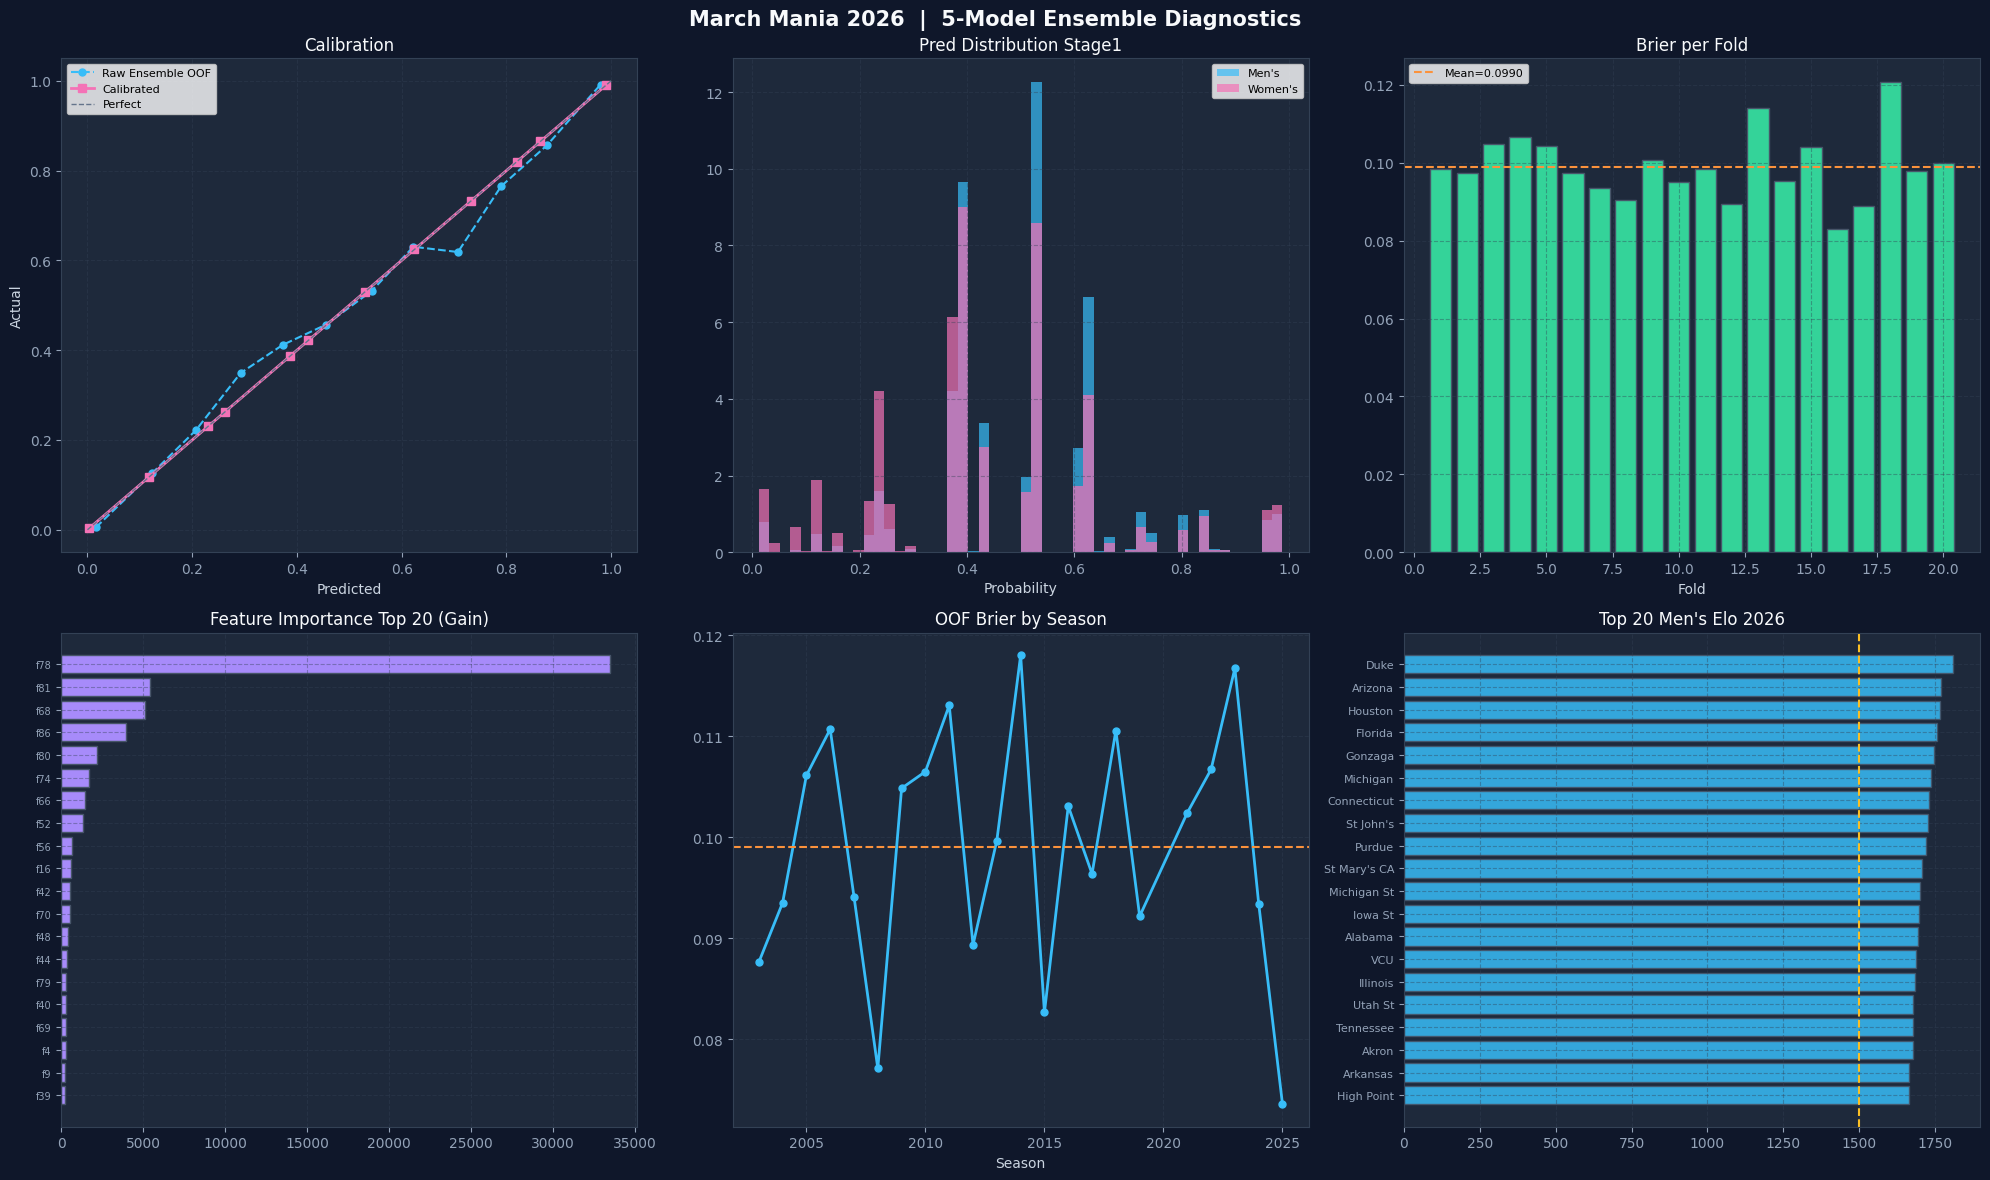


Done in 2121.0s
OOF Brier (cal): 0.09710
Submission saved -> submission_stage2.csv  (132,133 rows)


In [12]:
%matplotlib inline
fig, axes = plt.subplots(2, 3, figsize=(20, 12), facecolor='#0f172a')
fig.suptitle('March Mania 2026  |  5-Model Ensemble Diagnostics', color='#f8fafc', fontsize=15, fontweight='bold')
C = ['#38bdf8','#f472b6','#34d399','#fb923c','#a78bfa']
for ax in axes.flat:
    ax.set_facecolor('#1e293b')
    for sp in ax.spines.values(): sp.set_edgecolor('#334155')
    ax.grid(color='#334155', linestyle='--', alpha=0.4)
    ax.tick_params(colors='#94a3b8')
ax = axes[0,0]
fr, mp = calibration_curve(y, oof_ens, n_bins=12)
fc, mc = calibration_curve(y, oof_cal, n_bins=12)
ax.plot(mp, fr, 'o--', color=C[0], lw=1.5, ms=5, label='Raw Ensemble OOF')
ax.plot(mc, fc, 's-',  color=C[1], lw=2,   ms=6, label='Calibrated')
ax.plot([0,1],[0,1],'--',color='#64748b',lw=1,label='Perfect')
ax.set_title('Calibration', color='#f8fafc')
ax.set_xlabel('Predicted', color='#cbd5e1')
ax.set_ylabel('Actual', color='#cbd5e1')
ax.legend(fontsize=8)
ax = axes[0,1]
ax.hist(p1[sub1['T1']<3000], bins=50, color=C[0], alpha=0.7, density=True, label="Men's")
ax.hist(p1[sub1['T1']>=3000],bins=50, color=C[1], alpha=0.7, density=True, label="Women's")
ax.set_title('Pred Distribution Stage1', color='#f8fafc')
ax.set_xlabel('Probability', color='#cbd5e1')
ax.legend(fontsize=8)
ax = axes[0,2]
fold_briers = [brier_score_loss(y[vl], oof_ens[vl])
               for _, vl in skf.split(X_clean, y.astype(int))]
ax.bar(range(1,N_FOLDS+1), fold_briers, color=C[2], edgecolor='#475569')
ax.axhline(oof_brier, color=C[3], ls='--', lw=1.5, label=f'Mean={oof_brier:.4f}')
ax.set_title('Brier per Fold', color='#f8fafc')
ax.set_xlabel('Fold', color='#cbd5e1')
ax.legend(fontsize=8)
ax = axes[1,0]
top_idx = np.argsort(feat_imp)[-20:]
ax.barh(range(20), feat_imp[top_idx], color=C[4], edgecolor='#475569')
ax.set_yticks(range(20))
ax.set_yticklabels([f'f{i}' for i in top_idx], fontsize=7)
ax.set_title('Feature Importance Top 20 (Gain)', color='#f8fafc')
ax = axes[1,1]
uniq_s  = sorted(np.unique(s))
sb_vals = [brier_score_loss(y[s==ss], oof_ens[s==ss]) for ss in uniq_s if (s==ss).sum()>0]
ax.plot(uniq_s, sb_vals, marker='o', color=C[0], lw=2, ms=5)
ax.axhline(oof_brier, color=C[3], ls='--', lw=1.5)
ax.set_title('OOF Brier by Season', color='#f8fafc')
ax.set_xlabel('Season', color='#cbd5e1')
ax = axes[1,2]
top20 = (m_elo[m_elo['Season']==m_elo['Season'].max()].merge(mteam[['TeamID','TeamName']], on='TeamID').nlargest(20,'Elo').sort_values('Elo',ascending=True))
ax.barh(range(20), top20['Elo'], color=C[0], edgecolor='#475569', alpha=0.85)
ax.set_yticks(range(20))
ax.set_yticklabels(top20['TeamName'], fontsize=8)
ax.axvline(1500, color='#fbbf24', ls='--', lw=1.5)
ax.set_title("Top 20 Men's Elo 2026", color='#f8fafc')
plt.tight_layout()
plt.savefig(OUTPUT/'diagnostics.png', dpi=140, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
elapsed = time.time()-t0
print(f'\nDone in {elapsed:.1f}s')
print(f'OOF Brier (cal): {cal_brier:.5f}')
print(f'Submission saved -> submission_stage2.csv  ({len(out2):,} rows)')

In [13]:
src = '/kaggle/working/submission_stage2.csv'
df = pd.read_csv(src)[['ID','Pred']]
df.to_csv('/kaggle/working/submission.csv', index=False)
print(f'submission.csv ready  rows={len(df):,}')
print(df.head())

submission.csv ready  rows=132,133
               ID      Pred
0  2026_1101_1102  0.534247
1  2026_1101_1103  0.395210
2  2026_1101_1104  0.225490
3  2026_1101_1105  0.534247
4  2026_1101_1106  0.534247
